IMPORT LIBRARY

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator




Load dataset

In [3]:
dataset_path = "gambarhewan"

EDA

In [4]:
kelas = []
jumlah = []

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        total = len(os.listdir(folder_path))

        kelas.append(folder)
        jumlah.append(total)

        print(f"{folder}: {total} gambar")

anjing: 4863 gambar
ayam: 3098 gambar
domba: 1820 gambar
gajah: 1446 gambar
kucing: 1668 gambar
kuda: 2623 gambar
kupukupu: 2112 gambar
labalaba: 4821 gambar
sapi: 1866 gambar
tupai: 1862 gambar


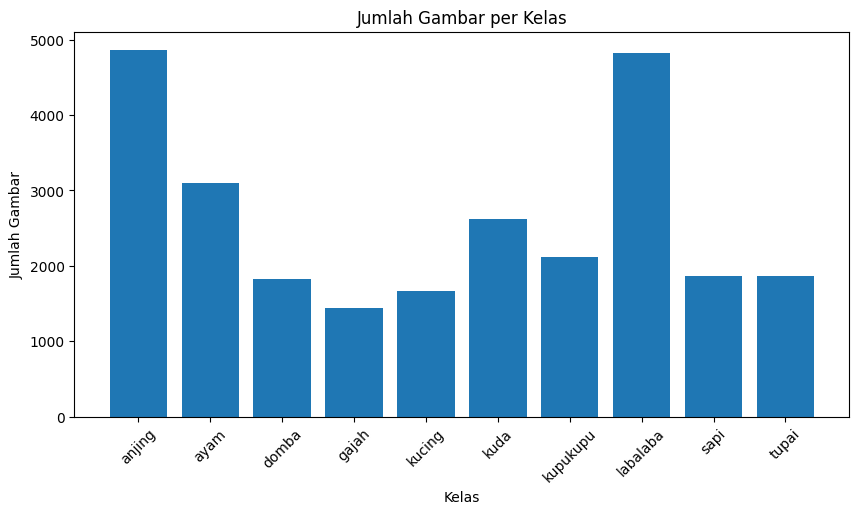

In [5]:
plt.figure(figsize=(10,5))

plt.bar(kelas, jumlah)

plt.title("Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")

plt.xticks(rotation=45)

plt.show()

DATA BALANCING

In [17]:
import os
import random
import shutil

dataset_path = "gambarhewan"
balanced_path = "dataset_balance"

TARGET = 1000

os.makedirs(balanced_path, exist_ok=True)

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        files = [f for f in os.listdir(folder_path)
                 if os.path.isfile(os.path.join(folder_path, f))]

        new_folder = os.path.join(balanced_path, folder)

        os.makedirs(new_folder, exist_ok=True)

        # Jika lebih dari 1000 gambar, ambil acak 1000
        if len(files) > TARGET:
            files = random.sample(files, TARGET)

        # Salin ke folder baru
        for file in files:

            src = os.path.join(folder_path, file)
            dst = os.path.join(new_folder, file)

            shutil.copy2(src, dst)

        print(f"{folder} -> {len(files)} gambar")

anjing -> 1000 gambar
ayam -> 1000 gambar
domba -> 1000 gambar
gajah -> 1000 gambar
kucing -> 1000 gambar
kuda -> 1000 gambar
kupukupu -> 1000 gambar
labalaba -> 1000 gambar
sapi -> 1000 gambar
tupai -> 1000 gambar


PREPROCESSING

In [18]:
import os

for folder in os.listdir("dataset_balance"):
    folder_path = os.path.join("dataset_balance", folder)

    if os.path.isdir(folder_path):
        print(folder, len(os.listdir(folder_path)))

anjing 1000
ayam 1000
domba 1000
gajah 1000
kucing 1000
kuda 1000
kupukupu 1000
labalaba 1000
sapi 1000
tupai 1000


In [19]:
dataset_path = "dataset_balance"

images = []
labels = []

IMG_SIZE = 150

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    for file in os.listdir(folder_path):

        img_path = os.path.join(folder_path, file)

        img = cv2.imread(img_path)

        if img is not None:

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            images.append(img)

            labels.append(folder)

print("Total gambar:", len(images))

Total gambar: 10000


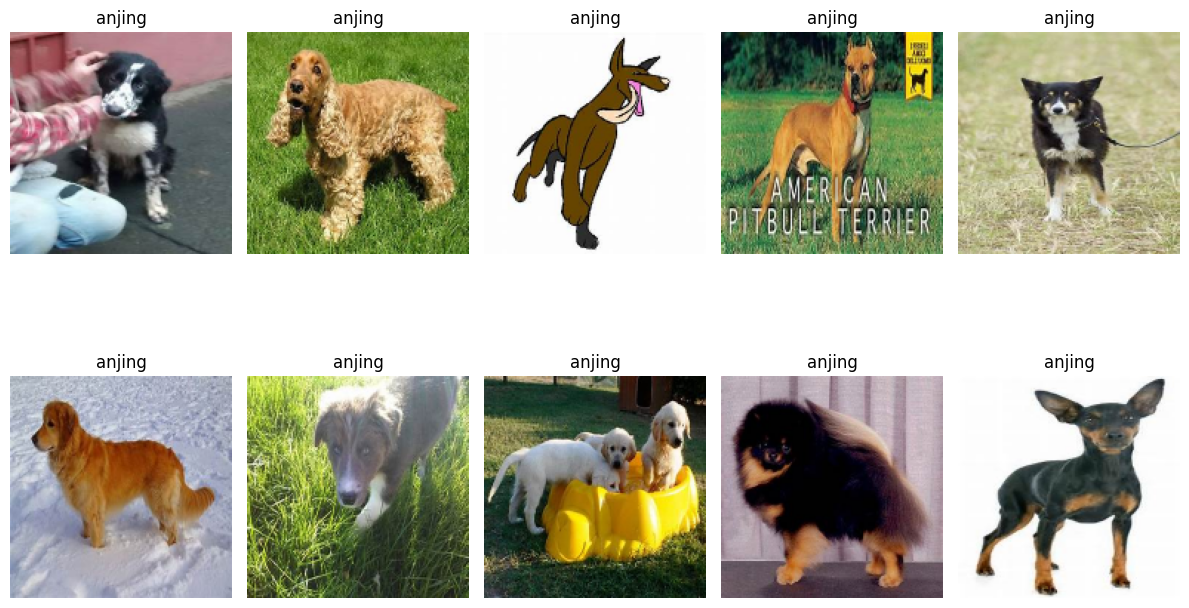

In [53]:
plt.figure(figsize=(12,8))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))

    plt.title(labels[i])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [54]:
X = np.array(images)
y = np.array(labels)

print(X.shape)
print(y.shape)

(10000, 150, 150, 3)
(10000,)


In [22]:
le = LabelEncoder()

y = le.fit_transform(y)

print("Jumlah kelas:", len(le.classes_))
print(le.classes_)

Jumlah kelas: 10
['anjing' 'ayam' 'domba' 'gajah' 'kucing' 'kuda' 'kupukupu' 'labalaba'
 'sapi' 'tupai']


In [23]:
X = X.astype("float32") / 255.0

print("Normalisasi selesai")


Normalisasi selesai


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Train:", X_train.shape)
print("Data Test :", X_test.shape)

Data Train: (8000, 150, 150, 3)
Data Test : (2000, 150, 150, 3)


DATA AUGMENTATION

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

MODEL CNN

In [26]:
cnn = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(150,150,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

Conv2D(
        256,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        10,
        activation='softmax'
    )
])

C:\Users\ACER\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,995,466 (7.61 MB)

 Trainable params: 1,995,466 (7.61 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = cnn.fit(
    datagen.flow(
        X_train,
        y_train,
        batch_size=32
    ),

    epochs=30,

    validation_data=(
        X_test,
        y_test
    )
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 230s 916ms/step - accuracy: 0.1489 - loss: 2.2472 - val_accuracy: 0.2155 - val_loss: 2.1567
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 154s 615ms/step - accuracy: 0.2183 - loss: 2.1157 - val_accuracy: 0.2970 - val_loss: 1.9570
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.2884 - loss: 1.9479 - val_accuracy: 0.3550 - val_loss: 1.7588
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 173s 694ms/step - accuracy: 0.3441 - loss: 1.8303 - val_accuracy: 0.4360 - val_loss: 1.5834
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 89s 357ms/step - accuracy: 0.3839 - loss: 1.7289 - val_accuracy: 0.4480 - val_loss: 1.5830
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 90s 360ms/step - accuracy: 0.4044 - loss: 1.6721 - val_accuracy: 0.4645 - val_loss: 1.5104
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 96s 384ms/step - accuracy: 0.4371 - loss: 1.6141 - val_accuracy: 0.4900 - val_loss: 1.4545
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 98s 390ms/step - accuracy: 0.4602 - loss: 

In [39]:
loss, acc = cnn.evaluate(
    X_test,
    y_test
)

print("Loss CNN :", loss)
print("Akurasi CNN :", acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.6765 - loss: 0.9802
Loss CNN : 0.9802440404891968
Akurasi CNN : 0.6765000224113464


GRAFIK_TEST

In [41]:
cnn.save("model_hewan.h5")

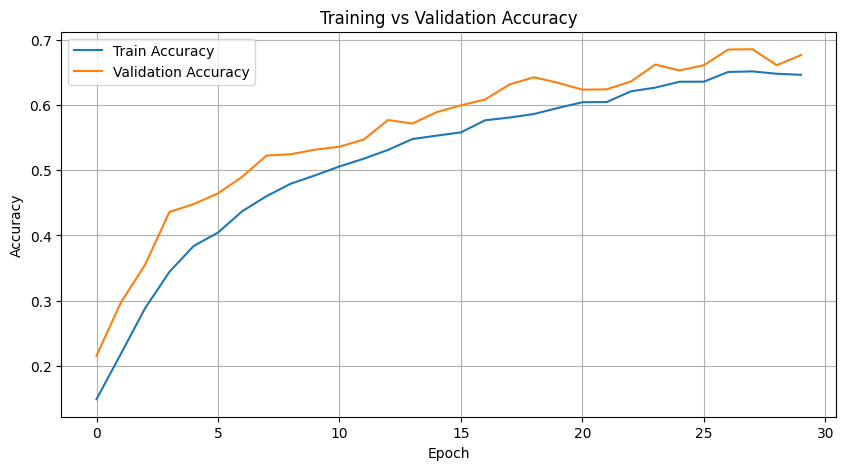

In [42]:
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

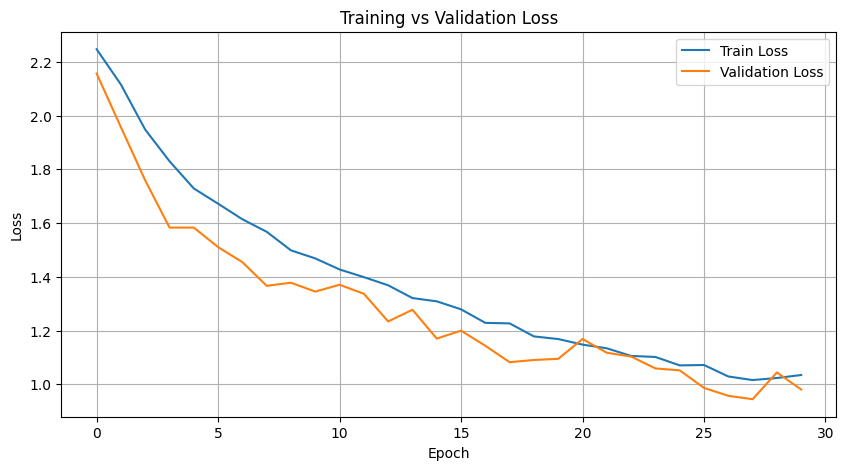

In [43]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [44]:
y_pred = cnn.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step


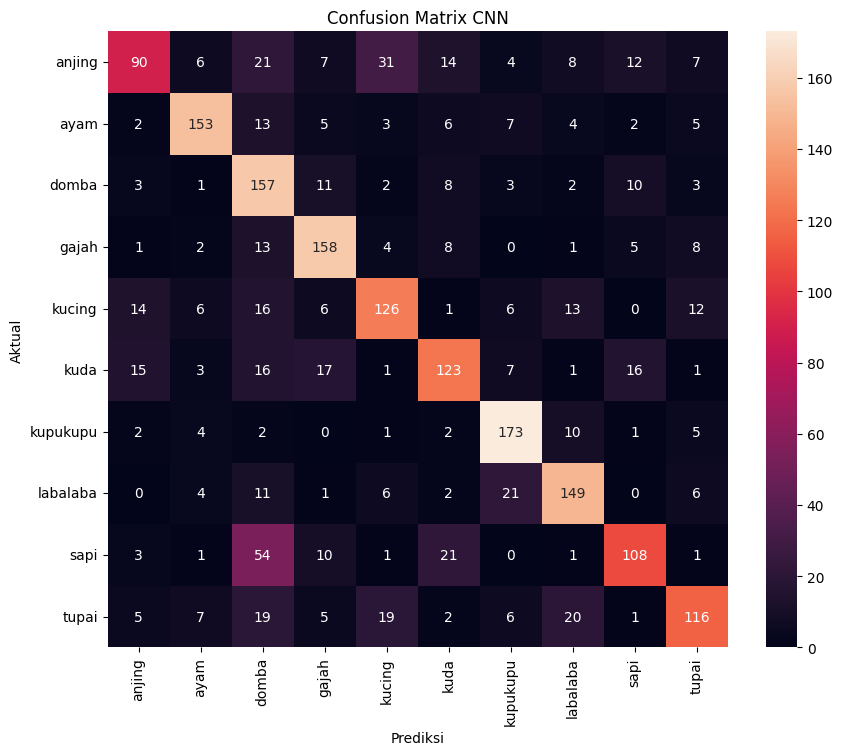

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix CNN")

plt.show()

In [46]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

      anjing       0.67      0.45      0.54       200
        ayam       0.82      0.77      0.79       200
       domba       0.49      0.79      0.60       200
       gajah       0.72      0.79      0.75       200
      kucing       0.65      0.63      0.64       200
        kuda       0.66      0.61      0.64       200
    kupukupu       0.76      0.86      0.81       200
    labalaba       0.71      0.74      0.73       200
        sapi       0.70      0.54      0.61       200
       tupai       0.71      0.58      0.64       200

    accuracy                           0.68      2000
   macro avg       0.69      0.68      0.67      2000
weighted avg       0.69      0.68      0.67      2000



In [47]:
cnn.save("model_hewan.h5")

In [48]:
import numpy as np

np.save("classes.npy", le.classes_)

In [49]:
print(le.classes_)

['anjing' 'ayam' 'domba' 'gajah' 'kucing' 'kuda' 'kupukupu' 'labalaba'
 'sapi' 'tupai']


In [50]:
import numpy as np

classes = np.load("classes.npy", allow_pickle=True)

print(classes)

['anjing' 'ayam' 'domba' 'gajah' 'kucing' 'kuda' 'kupukupu' 'labalaba'
 'sapi' 'tupai']


In [51]:
idx = 0

plt.imshow(x_test[idx])
plt.show()

pred = cnn.predict(np.expand_dims(x_test[idx], axis=0))

print("Prediksi :", le.classes_[np.argmax(pred)])
print("Label Asli :", le.classes_[y_test[idx]])

NameError: name 'x_test' is not defined